In [4]:
import sys
sys.path.append("..")

from src.model import FighterPredictor
import pandas as pd



c:\Users\yashs\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import numpy as np

np.random.seed(42)
n = 200

fake_data = pd.DataFrame({
    "age": np.random.randint(21, 40, size=n),
    "strike_accuracy": np.random.randint(20, 90, size=n),
    "stance": np.random.choice(["orthodox", "southpaw"], size=n),
    "weight_class": np.random.choice(["lightweight", "welterweight", "middleweight", "heavyweight", "bantamweight"], size=n),
    "winner": np.random.choice([0, 1], size=n)
})

fake_data

,age,strike_accuracy,stance,weight_class,winner
0,27,30,orthodox,welterweight,0
1,35,76,southpaw,heavyweight,0
2,31,69,southpaw,heavyweight,1
3,28,42,southpaw,bantamweight,0
4,27,50,southpaw,lightweight,0
...,...,...,...,...,...
195,28,23,orthodox,welterweight,1
196,27,35,orthodox,welterweight,1
197,38,43,southpaw,lightweight,0
198,28,21,southpaw,welterweight,0


In [6]:
X = fake_data.drop(columns=["winner"])
y = fake_data["winner"]

predictor = FighterPredictor()
predictor.fit(X, y)

In [7]:
predictor.evaluate_logloss(X, y)

0.6984550379320588

In [8]:
predictor.evaluate_auc(X, y)

0.39803980398039807

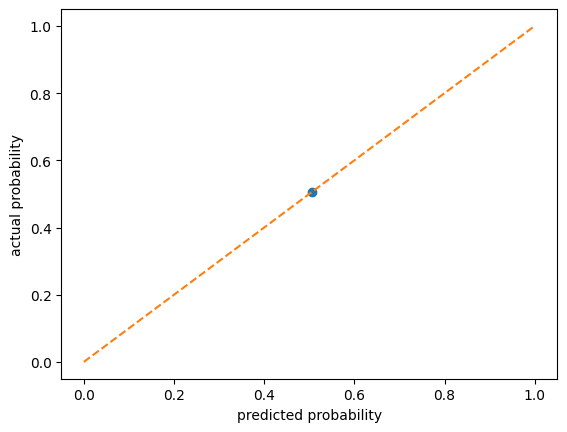

In [9]:
predictor.plot_calibration_curve(X, y)

In [10]:
predictor.predict_proba(X)

array([[0.6726489 , 0.32735112],
       [0.86930394, 0.13069607],
       [0.04478675, 0.95521325],
       [0.9166907 , 0.08330931],
       [0.98944473, 0.01055529],
       [0.954925  , 0.04507503],
       [0.09795481, 0.9020452 ],
       [0.8357264 , 0.16427365],
       [0.18405181, 0.8159482 ],
       [0.14047438, 0.8595256 ],
       [0.7535419 , 0.24645811],
       [0.8891153 , 0.11088474],
       [0.05616862, 0.9438314 ],
       [0.8785671 , 0.1214329 ],
       [0.9640098 , 0.03599019],
       [0.22342259, 0.7765774 ],
       [0.06129253, 0.9387075 ],
       [0.9822158 , 0.01778415],
       [0.16136712, 0.8386329 ],
       [0.9282301 , 0.07176987],
       [0.764555  , 0.23544501],
       [0.7778643 , 0.22213574],
       [0.09163982, 0.9083602 ],
       [0.7012065 , 0.2987935 ],
       [0.9753624 , 0.0246376 ],
       [0.96617967, 0.03382034],
       [0.03328639, 0.9667136 ],
       [0.09098428, 0.9090157 ],
       [0.03615046, 0.96384954],
       [0.1938982 , 0.8061018 ],
       [0.

In [14]:
#SHAP VALUES
contributions = predictor.get_shap_values(fake_data.head(3))
#predictor.pipeline.named_steps["preprocessor"].get_feature_names_out()
print(contributions)

[[-0.83991104 -0.24077271  0.76055276  0.          0.2069459  -0.078484
   0.0277434  -0.17737477 -0.40320054]
 [-0.92404133  0.11211535 -0.24193738  0.         -0.09212761 -0.6331782
   0.02408348 -0.17015517  0.00611142]
 [ 1.2915804   1.7451102  -0.3310214   0.          0.04037826  0.38957143
   0.07160336 -0.25486177  0.08334802]]
